In [55]:
import torch, torchvision
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
from torchvision import transforms
from torch.utils.data import DataLoader


from training import *
from training import ImageCSVDataset
from config import NUM_WORKERS, DEVICE, CLASS_NAMES
from utils import *

import os
import pandas as pd

In [ ]:
goodseed_train = sorted(os.listdir("dataset/batch1/train/GoodSeed"))
badseed_train = sorted(os.listdir("dataset/batch1/train/BadSeed"))
print(f"{len(goodseed_train)} good seeds")
print(f"{len(badseed_train)} bad seeds")
print(f"Training set: {len(goodseed_train) + len(badseed_train)} seeds.")

batch1_train_df = write_im_path(
    goodseed_train,
    badseed_train,
    csv_rel_path = "csv_folder/train.csv"
)

In [2]:
goodseed_test = sorted(os.listdir("dataset/batch1/test/GoodSeed"))
badseed_test = sorted(os.listdir("dataset/batch1/test/BadSeed"))
print(f"{len(goodseed_test)} good seeds")
print(f"{len(badseed_test)} bad seeds")
print(f"Testing set: {len(goodseed_test) + len(badseed_test)} seeds.")

201 good seeds
200 bad seeds
Testing set: 401 seeds.


In [ ]:
model_rn50_ffe = get_baseline_models(
    model_name="resnet50_ffe",
    none_weights=True
)
model_rn50_ffe.load_state_dict(torch.load(f"models/{"resnet50_ffe"}.pt", map_location=DEVICE))
model_rn50_ffe = model_rn50_ffe.to(DEVICE)
model_rn50_ffe.eval()
for param in model_rn50_ffe.parameters():
    param.requires_grad = True

In [4]:
model_rn50_mlp_ffe = get_baseline_models(
    model_name="resnet50_mlp_ffe",
    none_weights=True
)
model_rn50_mlp_ffe.load_state_dict(torch.load(f"models/{"resnet50_mlp_ffe"}.pt", map_location=DEVICE))
model_rn50_mlp_ffe = model_rn50_mlp_ffe.to(DEVICE)
model_rn50_mlp_ffe.eval()
for param in model_rn50_mlp_ffe.parameters():
    param.requires_grad = True

In [5]:
model_rn50_mlp = get_baseline_models(
    model_name="resnet50_mlp",
    none_weights=True
)
model_rn50_mlp.load_state_dict(torch.load(f"models/{"resnet50_mlp"}.pt", map_location=DEVICE))
model_rn50_mlp = model_rn50_mlp.to(DEVICE)
model_rn50_mlp.eval()
for param in model_rn50_mlp.parameters():
    param.requires_grad = True

In [ ]:
model_rn50 = get_baseline_models(
    model_name="resnet50",
    none_weights=True
)
model_rn50.load_state_dict(torch.load(f"models/{"resnet50"}.pt", map_location=DEVICE))
model_rn50 = model_rn50.to(DEVICE)
model_rn50.eval()
for param in model_rn50.parameters():
    param.requires_grad = True

In [ ]:
test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std =[0.229, 0.224, 0.225]),
])

batch1_test_df = write_im_path(
    goodseed_test,
    badseed_test,
    csv_rel_path = "csv_folder/test.csv"
)

img_dir = "dataset/batch1/test"

batch_size = 32
num_workers = 4

test_dataset = ImageCSVDataset(batch1_test_df, img_dir, transform=test_transform)

test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False,  num_workers=num_workers)



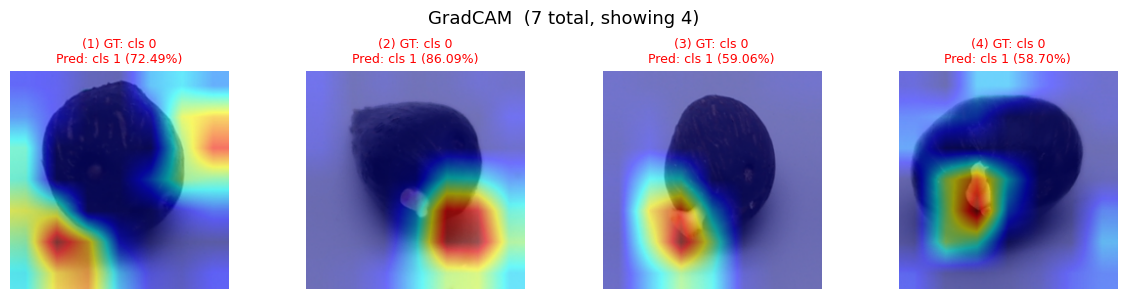

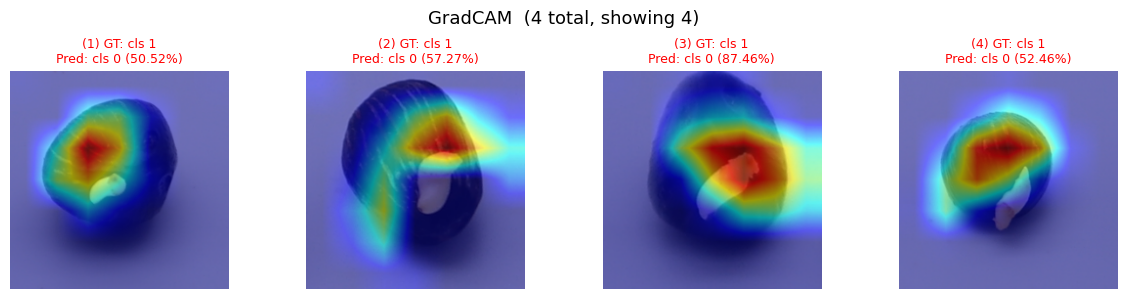

In [9]:


# model = model_rn50_ffe
# model = model_rn50_mlp_ffe
# model = model_rn50_mlp
model      = model_rn50 # Change this
model.eval()
model_name = [k for k, v in globals().items() if v is model][0]
criterion = nn.CrossEntropyLoss()
all_preds = []
all_labels = []
all_images = []  # store images too
all_outputs = []
total_loss = 0.0

with torch.no_grad():
    for images, labels in test_loader:   # <-- USE TEST LOADER
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        outputs = model(images)

        # classification
        preds = torch.argmax(outputs, dim=1)

        all_preds.append(preds.cpu())
        all_labels.append(labels.cpu())
        all_images.append(images.cpu())  # collect images
        all_outputs.append(outputs.cpu())

        loss = criterion(outputs, labels)
        total_loss += loss.item() * images.size(0)
    


all_preds  = torch.cat(all_preds)
all_labels = torch.cat(all_labels)
all_images = torch.cat(all_images)
all_outputs = torch.cat(all_outputs, dim=0)

all_probs = torch.softmax(all_outputs, dim=1)

# --- Failure cases ---
fp_mask = (all_preds == 1) & (all_labels == 0)
fn_mask = (all_preds == 0) & (all_labels == 1)
tp_mask = (all_preds == 1) & (all_labels == 1)
tn_mask = (all_preds == 0) & (all_labels == 0)


# High heat regions imply that the feature map activations in that region had large positive gradients w.r.t to logits


from itertools import product


layer_index = -1

all_cases = {
    "False Positive Cases": fp_mask,
    "False Negative Cases": fn_mask,
    "True Positive Cases":  tp_mask,
    "True Negative Cases":  tn_mask,
}

for case, layer_name, use_eigen, minimal_plots in product(
    ["False Positive Cases", "False Negative Cases"],
    ["layer4"],
    [False],
    [True],
):
    mask = all_cases[case]
    target_layer = getattr(model, layer_name)[layer_index]
    layer_label  = f"{layer_name}[{layer_index}]"
    cam_type     = "EigenCAM" if use_eigen    else "GradCAM"
    plot_style   = "Minimal"  if minimal_plots else "Full"
    num_images_plot = 4 if minimal_plots else 32


    fig = plot_cases_grad_eigen_cam(
        all_images[mask], all_preds[mask], all_labels[mask], all_probs[mask],
        model=model,
        title="",
        target_layer=target_layer,
        class_names=None,
        max_images=num_images_plot,
        ncols=4,
        eigen=use_eigen,
        minimal=minimal_plots,
    )


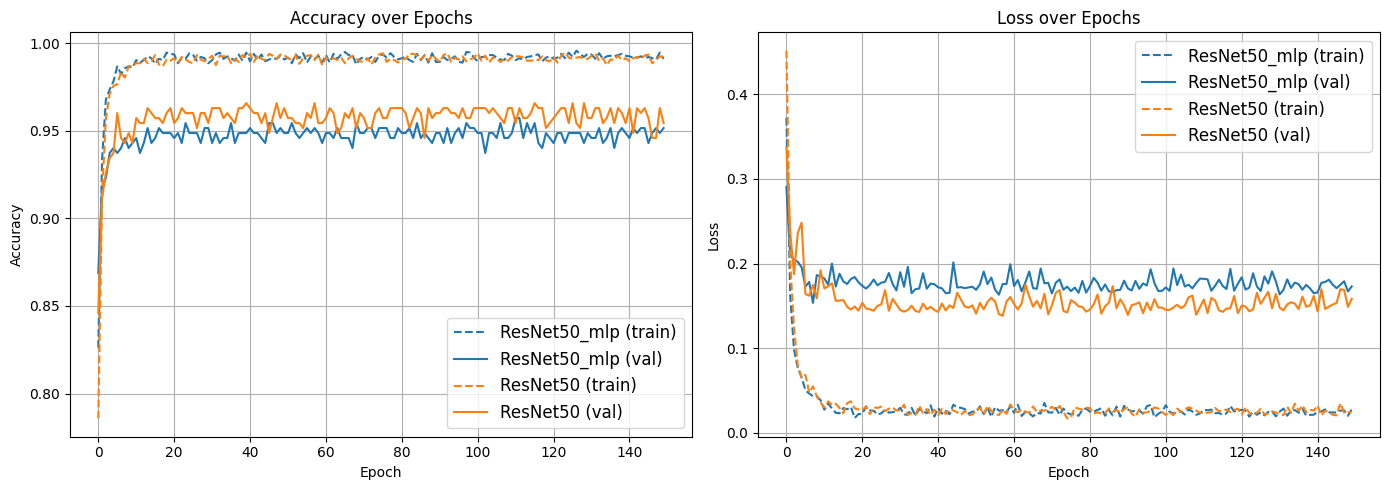

In [10]:
directories = [
    # "ckpts/ResNet50_ffe",
    # "ckpts/ResNet50_mlp_ffe",
    "ckpts/ResNet50_mlp",
    "ckpts/ResNet50"
]

import torch
import matplotlib.pyplot as plt
import os

os.makedirs("figs", exist_ok=True)
plot_histories(directories, fig_name = "figs/baseline_training_histories.png")

Evaluating RN50...


,Model,Loss,Accuracy,Precision,Recall,F1,AUC
0,RN50,0.058022,0.972569,0.965686,0.9801,0.97284,0.998209


,Model,Loss,Accuracy,Precision,Recall,F1,AUC
0,RN50,0.0580,0.9726,0.9657,0.9801,0.9728,0.9982


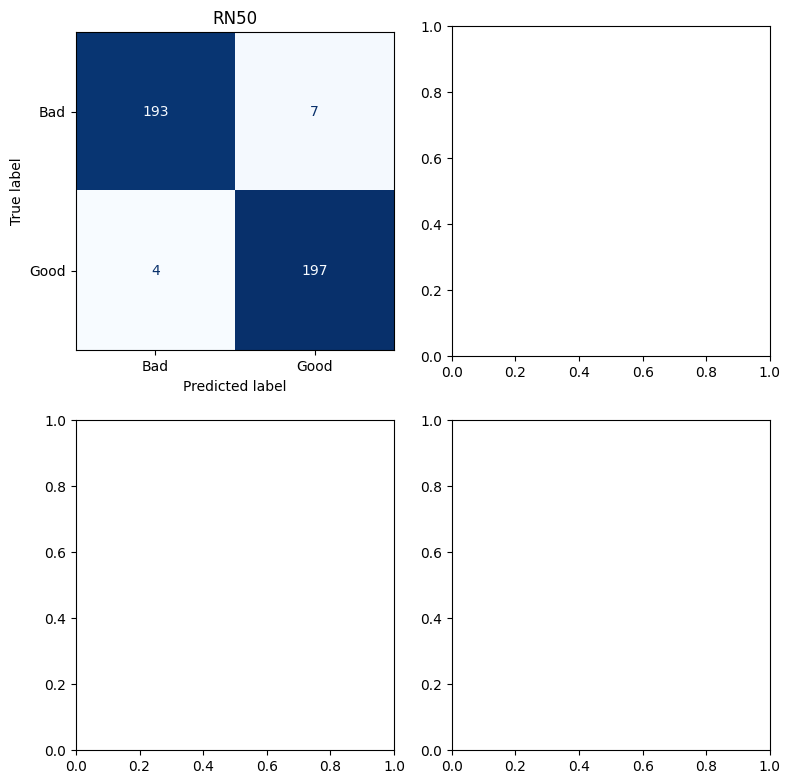

In [ ]:
# =========================================================
# Models in a dictionary
# =========================================================
models_dict = {
    "RN50": model_rn50,
    # "RN50_MLP": model_rn50_mlp,
    # "RN50_FFE": model_rn50_ffe,
    # "RN50_MLP_FFE": model_rn50_mlp_ffe,
}
model_order = list(models_dict.keys())

results_batch1 = {}
rows_batch1 = []

for model_name, model in models_dict.items():
    print(f"Evaluating {model_name}...")
    out = evaluate_model_batch1(model, test_loader, criterion, DEVICE)
    results_batch1[model_name] = out

    rows_batch1.append({
        "Model": model_name,
        "Loss": out["loss"],
        "Accuracy": out["accuracy"],
        "Precision": out["precision"],
        "Recall": out["recall"],
        "F1": out["f1"],
        "AUC": out["auc"],
    })


metrics_df = pd.DataFrame(rows_batch1)
metrics_df["Model"] = pd.Categorical(
    metrics_df["Model"],
    categories=model_order,
    ordered=True
)
metrics_df = metrics_df.sort_values("Model").reset_index(drop=True)

display(metrics_df)

# Optional nicer formatting
display(metrics_df.style.format({
    "Loss": "{:.4f}",
    "Accuracy": "{:.4f}",
    "Precision": "{:.4f}",
    "Recall": "{:.4f}",
    "F1": "{:.4f}",
    "AUC": "{:.4f}",
}))


fig, axes = plt.subplots(2, 2, figsize=(8, 8))
axes = axes.flatten()

model_order = list(models_dict.keys())

for ax, model_name in zip(axes, model_order):
    out = results_batch1[model_name]

    plot_confusion_matrix(
        out["cm"],
        ax=ax,
        class_names=("Bad", "Good"),
        title=model_name
    )

plt.tight_layout()
plt.show()

In [19]:
tree = None # initialise to None
df = None
erroneous_annotations = [
    rf"dataset/batch3/LightBox/Set19/SpaceOutRandom_GoodSeeds (s19)",
    rf"dataset/batch3/LightBox/Set14/SpaceOutRandom_GoodSeeds (s14)",
    rf"dataset/batch3/LightBox/Set12/SpaceOutRandom_GoodSeeds (s12)",
    rf"dataset/batch3/LightBox/Set19/Line_Mix (s19)",
    rf"dataset/batch3/LightBox/Set12/Line_Mix (s12)",
    rf"dataset/batch3/LightBox/Set4/Line_Mix (s4)",
]
jpg_path = ""
for batch_no in [2, 3]:
    if batch_no == 2:
        max_set = 15
    else:
        max_set = 20
    for set_no in range(1, max_set + 1):
        for seed_layout in ["Line", "SpaceOutRandom"]:
            
            for seed_class in ["Bad_Seeds", "Good_Seeds", "Mix"]:
                if batch_no == 2:
                    jpg_path = rf"dataset/batch{batch_no}/NormalRoomLighting/Set{set_no}/{seed_layout}_{seed_class} (s{set_no}).JPG"
                else:
                    jpg_path = rf"dataset/batch{batch_no}/LightBox/Set{set_no}/{seed_layout}_{seed_class.replace("_", "")} (s{set_no}).JPG"
                if jpg_path[:-4] in erroneous_annotations:
                    print(f"Skipped erroneous annotations. {jpg_path}")
                    continue
                df, bboxes = crop_and_save_to_df(batch_no, set_no, seed_layout, seed_class, df)

                    




Skipped erroneous annotations. dataset/batch3/LightBox/Set4/Line_Mix (s4).JPG
Skipped erroneous annotations. dataset/batch3/LightBox/Set12/Line_Mix (s12).JPG
Skipped erroneous annotations. dataset/batch3/LightBox/Set12/SpaceOutRandom_GoodSeeds (s12).JPG
Skipped erroneous annotations. dataset/batch3/LightBox/Set14/SpaceOutRandom_GoodSeeds (s14).JPG
Skipped erroneous annotations. dataset/batch3/LightBox/Set19/Line_Mix (s19).JPG
Skipped erroneous annotations. dataset/batch3/LightBox/Set19/SpaceOutRandom_GoodSeeds (s19).JPG


('dataset/batch3/LightBox/Set1/Line_BadSeeds (s1).JPG', 'dataset/batch3/LightBox/Set1/Line_BadSeeds (s1).JPG', 'dataset/batch3/LightBox/Set1/Line_BadSeeds (s1).JPG', 'dataset/batch3/LightBox/Set1/Line_BadSeeds (s1).JPG', 'dataset/batch3/LightBox/Set1/Line_BadSeeds (s1).JPG', 'dataset/batch3/LightBox/Set1/Line_BadSeeds (s1).JPG', 'dataset/batch3/LightBox/Set1/Line_BadSeeds (s1).JPG', 'dataset/batch3/LightBox/Set1/Line_BadSeeds (s1).JPG', 'dataset/batch3/LightBox/Set1/Line_BadSeeds (s1).JPG', 'dataset/batch3/LightBox/Set1/Line_BadSeeds (s1).JPG')


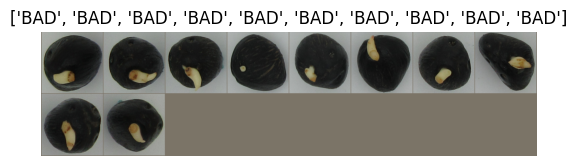

In [22]:
batch2_df, batch2_dataset, batch2_loader = make_batch(
    df, batch_no=2, img_dir="dataset/batch2/NormalRoomLighting", transform=test_transform
)

batch3_df, batch3_dataset, batch3_loader = make_batch(
    df, batch_no=3, img_dir="dataset/batch3/LightBox",          transform=test_transform
)

show_batch_grid(batch3_loader, CLASS_NAMES, n = 10)

Evaluating RN50...


,Model,Loss,Accuracy,Precision,Recall,F1,AUC
0,RN50,0.385117,0.851111,0.920213,0.768889,0.837772,0.945442


,Model,Loss,Accuracy,Precision,Recall,F1,AUC
0,RN50,0.3851,0.8511,0.9202,0.7689,0.8378,0.9454


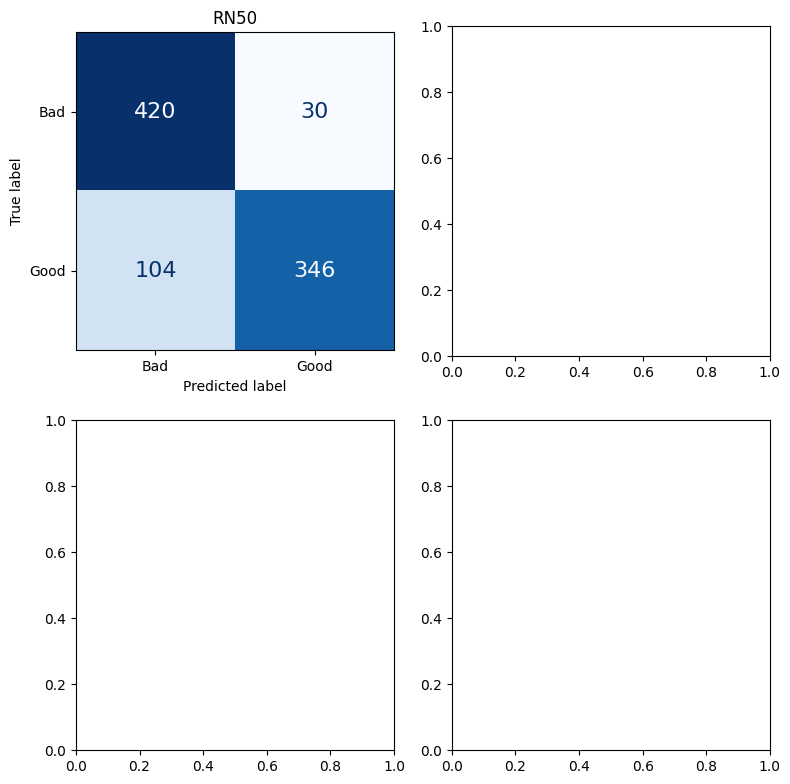

In [28]:
# =========================================================
# 1) Models + fixed order
# =========================================================
models_dict = {
    "RN50": model_rn50,
    # "RN50_MLP": model_rn50_mlp,
    # "RN50_FFE": model_rn50_ffe,
    # "RN50_MLP_FFE": model_rn50_mlp_ffe,
}

model_order = list(models_dict.keys()) 




# =========================================================
# 4) Evaluate models
# =========================================================
results_batch2 = {}
rows_batch2 = []

for model_name in model_order:
    model = models_dict[model_name]

    print(f"Evaluating {model_name}...")
    out = evaluate_model_b2b3(model, batch2_loader, criterion, DEVICE)

    results_batch2[model_name] = out

    rows_batch2.append({
        "Model": model_name,
        "Loss": out["loss"],
        "Accuracy": out["accuracy"],
        "Precision": out["precision"],
        "Recall": out["recall"],
        "F1": out["f1"],
        "AUC": out["auc"],
    })


# =========================================================
# 5) Metrics table (FIXED ORDER)
# =========================================================
batch2_metrics_df = pd.DataFrame(rows_batch2)

batch2_metrics_df["Model"] = pd.Categorical(
    batch2_metrics_df["Model"],
    categories=model_order,
    ordered=True
)

batch2_metrics_df = batch2_metrics_df.sort_values("Model").reset_index(drop=True)

display(batch2_metrics_df)

display(batch2_metrics_df.style.format({
    "Loss": "{:.4f}",
    "Accuracy": "{:.4f}",
    "Precision": "{:.4f}",
    "Recall": "{:.4f}",
    "F1": "{:.4f}",
    "AUC": "{:.4f}",
}))


# =========================================================
# 6) 2x2 Confusion Matrix Grid (FIXED ORDER)
# =========================================================
fig, axes = plt.subplots(2, 2, figsize=(8, 8))
axes = axes.flatten()

for ax, model_name in zip(axes, model_order):
    out = results_batch2[model_name]

    plot_confusion_matrix(
        out["cm"],
        ax=ax,
        class_names=("Bad", "Good"),
        title=model_name
    )

plt.tight_layout()
plt.show()

In [38]:
byol_dataset = ImageCSVDataset(pd.read_csv("csv_folder/train.csv"), img_dir = "dataset/batch1/train", transform=BYOL_Transform()) 
byol_dataloader = DataLoader(byol_dataset, batch_size = 32, shuffle=True,
                           num_workers=NUM_WORKERS)

2
torch.Size([32, 3, 224, 224])
torch.Size([32, 3, 224, 224])


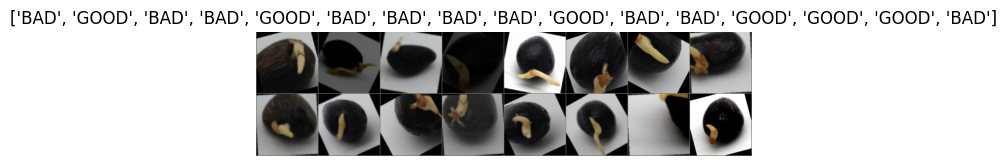

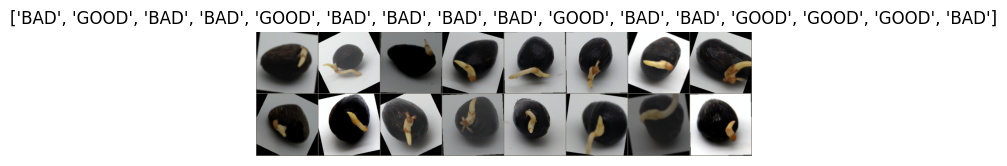

In [39]:
n = 16

paired_views, labels = next(iter(byol_dataloader))
print(len(paired_views))
print(paired_views[0].shape)
print(paired_views[1].shape)
out1 = torchvision.utils.make_grid(paired_views[0][:n])
out2 = torchvision.utils.make_grid(paired_views[1][:n])
imshow(out1, title = [CLASS_NAMES[x] for x in labels[:n]])
imshow(out2, title = [CLASS_NAMES[x] for x in labels[:n]])

In [40]:
byol = BYOL()
byol.to(DEVICE);

In [41]:
trained_encoder = get_encoder_model()
byol_encoder_path = r"models/byol_encoder.pt"
if not os.path.exists(byol_encoder_path):
    byol, history = train_self_supervised(byol,byol_dataloader,num_epochs=100)
    trained_encoder.load_state_dict(byol.online_network.encoder.state_dict())
    torch.save(trained_encoder.state_dict(), byol_encoder_path)
else:
    trained_encoder.load_state_dict(torch.load(byol_encoder_path, map_location=DEVICE))

In [42]:
trained_encoder.to(DEVICE)
seed_clf = Classifier(trained_encoder)
seed_clf.to(DEVICE)

Classifier(
  (encoder): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Sequential(
       

In [44]:
seed_clf_save_dir = r"models/byol_tuned_seed_clf.pt"
if not os.path.exists(seed_clf_save_dir):
    optimizer = optim.SGD(
        seed_clf.parameters(),
        lr=0.001,
        momentum=0.9
    )
    # Decay LR by a factor of 0.1 every 10 epochs
    exp_lr_scheduler = lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)
    seed_clf, history = train_model(
        seed_clf,
        crtrn=nn.CrossEntropyLoss(),
        optimizer=optimizer,
        scheduler=exp_lr_scheduler,
        num_epochs=50,
        checkpoint_dir='ckpts'
    )
    torch.save(seed_clf.state_dict(), seed_clf_save_dir)
else:
    seed_clf = Classifier(get_encoder_model())
    seed_clf.load_state_dict(torch.load(seed_clf_save_dir, map_location=DEVICE))
    

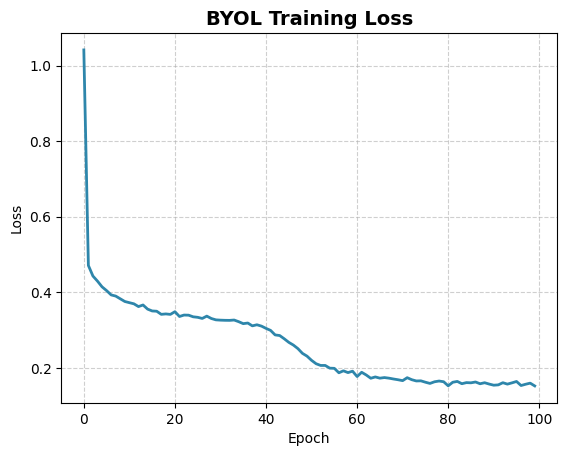

In [46]:
history_byol = torch.load("ckpts/byol/history.pth")
plt.plot(history_byol["train_loss"], linewidth=2, color='#2E86AB')
plt.title("BYOL Training Loss", fontsize=14, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.6)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.savefig("figs/byol_train_loss.png", dpi=300, bbox_inches='tight')

In [47]:
print(history_byol["train_loss"][-1])

0.15219086503440685


In [ ]:
seed_clf.to(DEVICE)
seed_clf_results_b1 = evaluate_model_batch1(
    model = seed_clf,
    loader = test_loader, 
    criterion=nn.CrossEntropyLoss(),
    DEVICE=DEVICE
)
seed_clf_results_b1

{'loss': 0.03501598323588526,
 'accuracy': 0.9850374064837906,
 'precision': 0.975609756097561,
 'recall': 0.9950248756218906,
 'f1': 0.9852216748768473,
 'auc': np.float64(0.9995024875621891),
 'cm': array([[195,   5],
        [  1, 200]]),
 'preds': tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
         1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
         1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
         1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
         1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
         1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
         1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
         1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
         1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0,

In [ ]:
seed_clf_results_b2 = evaluate_model_b2b3(
    model = seed_clf,
    loader = batch2_loader, 
    criterion=nn.CrossEntropyLoss(),
    DEVICE=DEVICE
)
seed_clf_results_b2

{'loss': 0.28676774190531834,
 'accuracy': 0.8855555555555555,
 'precision': 0.8813186813186813,
 'recall': 0.8911111111111111,
 'f1': 0.8861878453038674,
 'auc': np.float64(0.9501333333333333),
 'cm': array([[396,  54],
        [ 49, 401]]),
 'preds': tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
         0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1,
         1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1,
         1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0,
         0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0,
         1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1,
         0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1,
         1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1,
         1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0

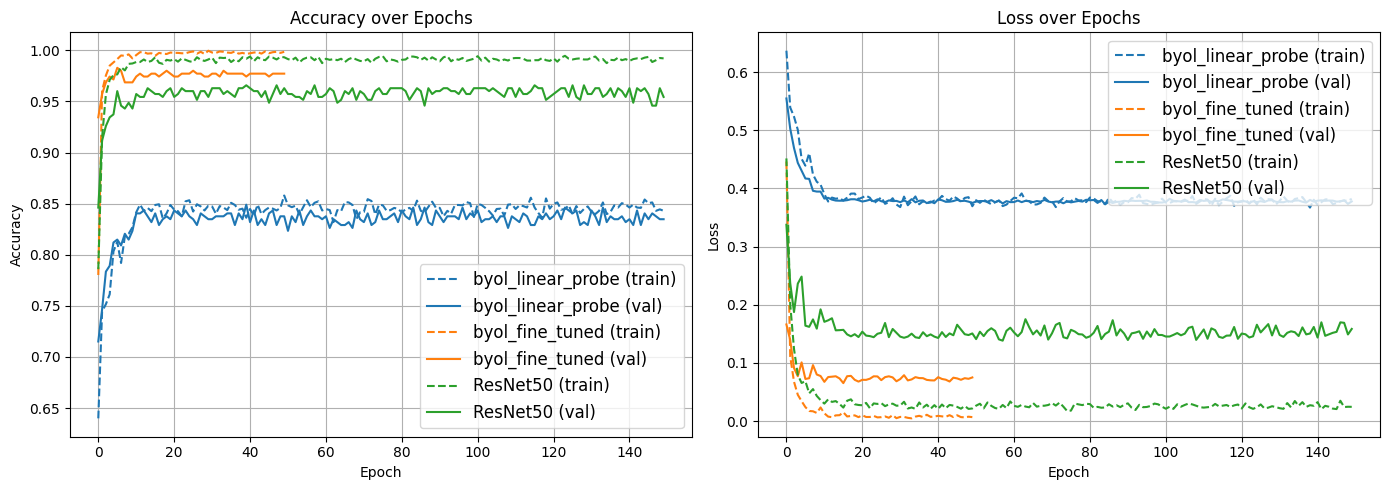

In [51]:
directories = [
    "ckpts/byol_linear_probe",
    "ckpts/byol_fine_tuned",
    "ckpts/ResNet50"
]
plot_histories(directories, "byol_training_histories")

In [53]:
# tuned_encoder = copy.deepcopy(seed_clf.encoder)

tuned_encoder = Classifier(get_encoder_model())
tuned_encoder.load_state_dict(torch.load("models/byol_tuned_seed_clf.pt", map_location=DEVICE))
tuned_encoder = tuned_encoder.encoder
tuned_encoder.to(DEVICE)


byol_finetuned_embeddings_b1, byol_finetuned_labels_b1 = get_encoder_embeddings(tuned_encoder, dataloader = test_loader, device = DEVICE)
byol_finetuned_embeddings_b2, byol_finetuned_labels_b2 = get_encoder_embeddings_b2b3(tuned_encoder, dataloader = batch2_loader, device = DEVICE)
byol_finetuned_embeddings_b3, byol_finetuned_labels_b3 = get_encoder_embeddings_b2b3(tuned_encoder, dataloader = batch3_loader, device = DEVICE)



In [54]:
cluster_assg_b1_byol, sim_scores_b1_byol = kmeans_embeddings(byol_finetuned_embeddings_b1, byol_finetuned_labels_b1, n_clusters=2)
cluster_assg_b2_byol, sim_scores_b2_byol = kmeans_embeddings(byol_finetuned_embeddings_b2, byol_finetuned_labels_b2, n_clusters=2)
cluster_assg_b3_byol, sim_scores_b3_byol = kmeans_embeddings(byol_finetuned_embeddings_b3, byol_finetuned_labels_b3, n_clusters=2)

print(f"{'':20} {'Batch-1':>10} {'Batch-2':>10} {'Batch-3':>10}")
print("-" * 50)
print(f"{'ARI':20} {sim_scores_b1_byol['ari']:>10.4f} {sim_scores_b2_byol['ari']:>10.4f} {sim_scores_b3_byol['ari']:>10.4f}")
print(f"{'NMI':20} {sim_scores_b1_byol['nmi']:>10.4f} {sim_scores_b2_byol['nmi']:>10.4f} {sim_scores_b3_byol['nmi']:>10.4f}")

                        Batch-1    Batch-2    Batch-3
--------------------------------------------------
ARI                      0.9216     0.5406     0.4133
NMI                      0.8677     0.5311     0.3824
